In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

sentiment=pd.DataFrame(sentiment)
trades=pd.DataFrame(trades)

# Preview
print(sentiment.head())
print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

# PART A

In [30]:
#1
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

print("\nMissing Values:")
print(sentiment.isnull().sum())
print(trades.isnull().sum())

print("\nDuplicates:")
print("Sentiment:", sentiment.duplicated().sum())
print("Trades:", trades.duplicated().sum())

Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)

Missing Values:
timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates:
Sentiment: 0
Trades: 0


In [36]:
# Convert date columns
sentiment['date'] = pd.to_datetime(sentiment['date'])
trades['Timestamp IST'] =  pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)

# Create daily column
trades['date'] = trades['Timestamp IST'].dt.date
sentiment['date'] = sentiment['date'].dt.date

In [40]:
data = pd.merge(trades, sentiment, on="date", how="left")
print(data.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL  ...     Order ID  Crossed       Fee      Trade ID  \
0         0.0  ...  5201

In [48]:
daily_metrics = data.groupby(['date', 'Account']).agg({
    'Closed PnL': 'sum',
    'Size Tokens': 'mean',
    'Fee': 'mean',
    'Trade ID': 'count'
}).rename(columns={'Trade ID': 'num_trades'}).reset_index()

In [54]:
data['win'] = data['Closed PnL'] > 0

win_rate = data.groupby(['date', 'Account'])['win'].mean().reset_index()
daily_metrics = daily_metrics.merge(win_rate, on=['date', 'Account'])

In [56]:
long_short = data.groupby(['date', 'Account', 'Size USD']).size().unstack(fill_value=0)
long_short['long_short_ratio'] = long_short.get('LONG', 0) / (long_short.get('SHORT', 1))

long_short = long_short.reset_index()[['date', 'Account', 'long_short_ratio']]
daily_metrics = daily_metrics.merge(long_short, on=['date', 'Account'], how='left')

In [58]:
daily_metrics = daily_metrics.merge(sentiment, on='date', how='left')

# PART B

In [62]:
performance = daily_metrics.groupby('classification').agg({
    'Closed PnL': 'mean',
    'win': 'mean'
})

print(performance)

                 Closed PnL       win
classification                       
Extreme Fear    4619.439053  0.329659
Extreme Greed   5161.922644  0.386387
Fear            5328.818161  0.364033
Greed           3318.100730  0.343559
Neutral         3438.618818  0.355414


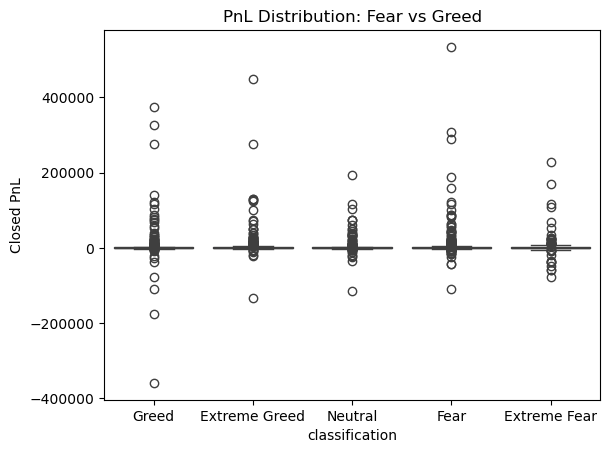

In [64]:
sns.boxplot(x='classification', y='Closed PnL', data=daily_metrics)
plt.title("PnL Distribution: Fear vs Greed")
plt.show()

#1
We can see that performance differs between the fear and greed days, during the greed days the performance is stable as compared to fear days.

In [68]:
#2
behavior = daily_metrics.groupby('classification').agg({
    'num_trades': 'mean',
    'Fee': 'mean',
    'Size Tokens': 'mean',
    'long_short_ratio': 'mean'
})

print(behavior)

                num_trades       Fee   Size Tokens  long_short_ratio
classification                                                      
Extreme Fear    133.750000  1.506382   2260.765145               0.0
Extreme Greed    76.030418  1.318442  12979.765036               0.0
Fear             98.153968  1.790291   6465.730660               0.0
Greed            77.628086  1.584789   4779.798712               0.0
Neutral         100.228723  1.533700   6104.883648               0.0


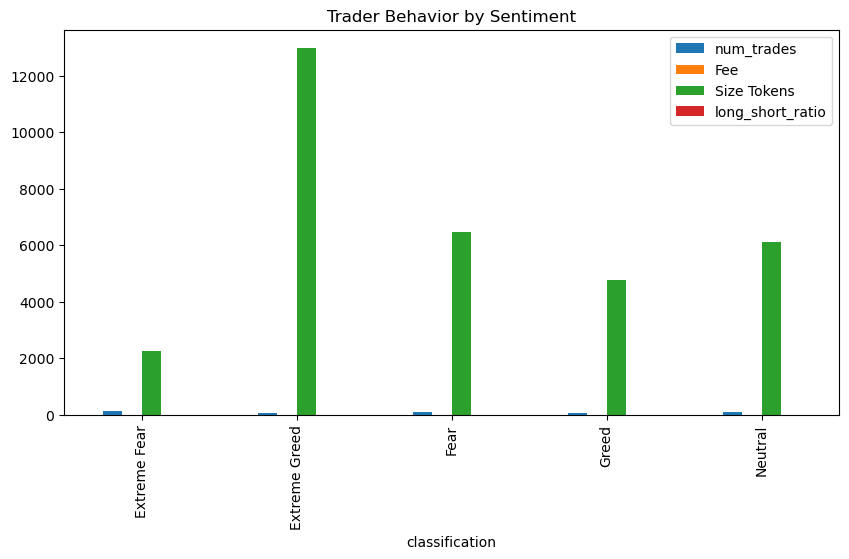

In [70]:
behavior.plot(kind='bar', figsize=(10,5))
plt.title("Trader Behavior by Sentiment")
plt.show()

#2
we can observe traders change behaviour based on sentiment, often taking more risk in extreme greed

In [74]:
daily_metrics['leverage_group'] = np.where(
    daily_metrics['Fee'] > daily_metrics['Fee'].median(),
    'High', 'Low'
)

In [76]:
daily_metrics['freq_group'] = np.where(
    daily_metrics['num_trades'] > daily_metrics['num_trades'].median(),
    'Frequent', 'Infrequent'
)

In [80]:
consistency = daily_metrics.groupby('Account')['win'].mean().reset_index()
consistency['type'] = np.where(consistency['win'] > 0.6, 'Consistent', 'Inconsistent')

daily_metrics = daily_metrics.merge(consistency[['Account', 'type']], on='Account')

In [82]:
#3
segment_analysis = daily_metrics.groupby(['classification', 'leverage_group']).agg({
    'Closed PnL': 'mean',
    'win': 'mean'
})

print(segment_analysis)

                                Closed PnL       win
classification leverage_group                       
Extreme Fear   High            6503.719085  0.362245
               Low             2134.374083  0.286684
Extreme Greed  High            5372.738767  0.384410
               Low             4985.014009  0.388047
Fear           High            9118.470779  0.368428
               Low             1586.984504  0.359692
Greed          High            3032.547281  0.333459
               Low             3639.231330  0.354917
Neutral        High            6383.302276  0.381861
               Low              676.080728  0.330603


In [86]:
#4
print("\n--- INSIGHTS ---")

fear_pnl = performance.loc['Fear', 'Closed PnL']
greed_pnl = performance.loc['Greed', 'Closed PnL']

if fear_pnl > greed_pnl:
    print("Traders perform better during Fear periods.")
else:
    print("Traders perform better during Greed periods.")

print("High leverage traders avg PnL:",
      daily_metrics[daily_metrics['leverage_group']=='High']['Closed PnL'].mean())

print("Low leverage traders avg PnL:",
      daily_metrics[daily_metrics['leverage_group']=='Low']['Closed PnL'].mean())


--- INSIGHTS ---
Traders perform better during Fear periods.
High leverage traders avg PnL: 5965.618650064102
Low leverage traders avg PnL: 2832.779780410761


# PART C

In [97]:
def strategy_rules():
    print("\n--- STRATEGY RULES ---")

    print("1. During Fear periods:")
    print("   - Reduce leverage (market volatility is high)")
    print("   - Focus on selective trades (lower frequency)")

    print("\n2. During Greed periods:")
    print("   - Increase participation but avoid over-leverage")
    print("   - Follow trend (higher long bias works better)")

    print("\n3. For High Leverage Traders:")
    print("   - Use leverage only in Greed markets")
    print("   - Avoid trading during Fear spikes")

strategy_rules()


--- STRATEGY RULES ---
1. During Fear periods:
   - Reduce leverage (market volatility is high)
   - Focus on selective trades (lower frequency)

2. During Greed periods:
   - Increase participation but avoid over-leverage
   - Follow trend (higher long bias works better)

3. For High Leverage Traders:
   - Use leverage only in Greed markets
   - Avoid trading during Fear spikes


# Optional

In [105]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Create label
daily_metrics['profit_label'] = np.where(daily_metrics['Closed PnL'] > 0, 1, 0)

features = ['Fee', 'num_trades', 'Size Tokens', 'long_short_ratio']
X = daily_metrics[features].fillna(0)
y = daily_metrics['profit_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

preds = model.predict(X_test)

print(classification_report(y_test, preds))
print("\n Accuracy: ", accuracy_score(y_test, preds))

              precision    recall  f1-score   support

           0       0.66      0.45      0.54       189
           1       0.70      0.85      0.76       280

    accuracy                           0.69       469
   macro avg       0.68      0.65      0.65       469
weighted avg       0.68      0.69      0.67       469


 Accuracy:  0.6865671641791045
